In [1]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("aryashah2k/soybean-seedsclassification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'soybean-seedsclassification-dataset' dataset.
Path to dataset files: /kaggle/input/soybean-seedsclassification-dataset
Contents of base_path (/kaggle/input):
['soybean-seedsclassification-dataset']
Contents of path (/kaggle/input/soybean-seedsclassification-dataset):
['Immature soybeans', 'Intact soybeans', 'Skin-damaged soybeans', 'Spotted soybeans', 'Broken soybeans']


In [2]:
import os

# Use 'path' directly as classes are located here
data_path = path

# List soybean class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Soybean classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Soybean classes found: ['Immature soybeans', 'Intact soybeans', 'Skin-damaged soybeans', 'Spotted soybeans', 'Broken soybeans']



--- Displaying Sample Images from Dataset (/kaggle/input/soybean-seedsclassification-dataset) ---
Found 5513 images. Displaying 6 sample images:


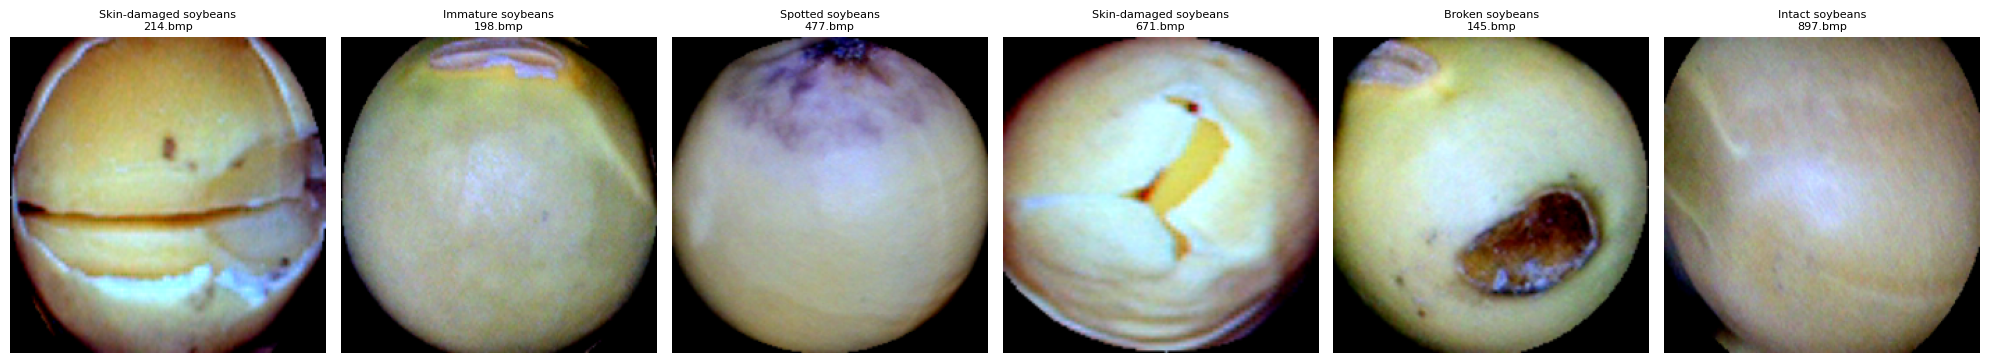

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct path identified in the previous cell
data_path = path
print(f"\n--- Displaying Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [4]:
!pip install split-folders

In [5]:
import splitfolders

# Define the output folder
output_folder = "soybean_split"

# Split with a ratio of 0.8 for train and 0.2 for val (test)
# seed=1337 ensures reproducibility
splitfolders.ratio(data_path, output=output_folder, seed=1337, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Dataset successfully split! Check the '{output_folder}' directory.")

Copying files: 5513 files [00:41, 134.43 files/s]

Dataset successfully split! Check the 'soybean_split' directory.


In [6]:
# Verify the split results
for split in ['train', 'val']:
    print(f"\n--- {split.upper()} set ---")
    split_path = os.path.join(output_folder, split)
    for class_name in os.listdir(split_path):
        count = len(os.listdir(os.path.join(split_path, class_name)))
        print(f"{class_name}: {count} images")


--- TRAIN set ---
Broken soybeans: 801 images
Spotted soybeans: 846 images
Skin-damaged soybeans: 901 images
Immature soybeans: 900 images
Intact soybeans: 960 images

--- VAL set ---
Broken soybeans: 201 images
Spotted soybeans: 212 images
Skin-damaged soybeans: 226 images
Immature soybeans: 225 images
Intact soybeans: 241 images


In [7]:
import tensorflow as tf

# Check GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Check your runtime settings.')
else:
  print('Found GPU at: {}'.format(device_name))

# Set mixed precision if GPU is capable
from tensorflow.keras import mixed_precision
try:
    mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision enabled')
except:
    print('Mixed precision not supported')

Found GPU at: /device:GPU:0
Mixed precision enabled


In [8]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers

# Configuration
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
NUM_CLASSES = 5
EPOCHS = 10

# Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'soybean_split/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    'soybean_split/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build Inception Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

Found 4408 images belonging to 5 classes.
Found 1105 images belonging to 5 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 142s 853ms/step - accuracy: 0.5800 - loss: 1.1214 - val_accuracy: 0.6535 - val_loss: 0.8174
Epoch 2/10
  1/137 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7500 - loss: 0.7281

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7500 - loss: 0.7281 - val_accuracy: 0.6471 - val_loss: 0.7958
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 93s 677ms/step - accuracy: 0.6748 - loss: 0.8265 - val_accuracy: 0.6893 - val_loss: 0.7612
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6562 - loss: 1.0260 - val_accuracy: 0.7270 - val_loss: 0.7131
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 93s 678ms/step - accuracy: 0.7027 - loss: 0.7401 - val_accuracy: 0.6783 - val_loss: 0.8017
Epoch 6/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6562 - loss: 0.8159 - val_accuracy: 0.6618 - val_loss: 0.8312
Epoch 7/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 92s 671ms/step - accuracy: 0.7283 - loss: 0.6862 - val_accuracy: 0.6801 - val_loss: 0.7307
Epoch 8/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6250 - loss: 0.9292 - val_accuracy: 0.6682 - val_loss: 0.7673
Epoch 9/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 92s 674ms/step - accuracy: 0.7301 - loss: 0.6839 - val_accurac

In [9]:
# Evaluate the model
loss, accuracy = model.evaluate(validation_generator)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 453ms/step - accuracy: 0.7629 - loss: 0.6392
Final Validation Loss: 0.6392
Final Validation Accuracy: 0.7629


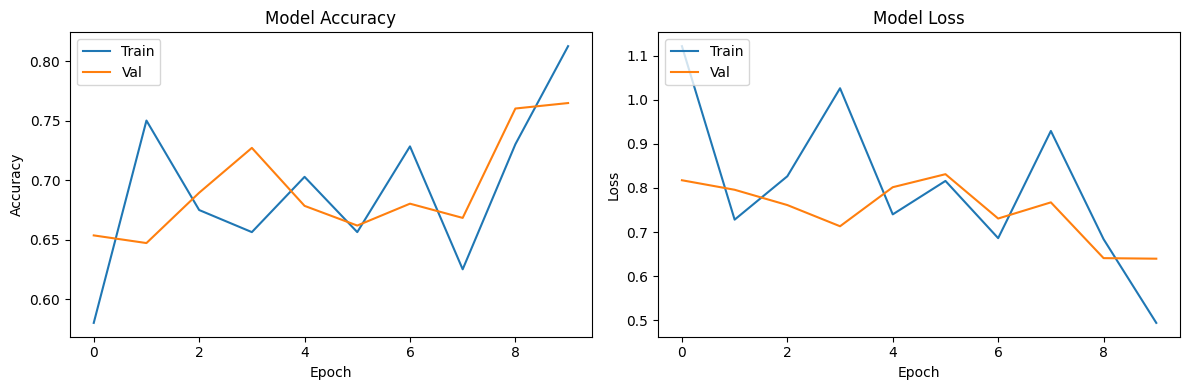

In [10]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

plt.tight_layout()
plt.show()